# 機器學習入門實作流程

##專題背景與目標

本資料集用「抗藥性菌株資料」練習從資料到模型的完整流程。任務：預測是否屬於 MDR（多重抗藥，≥3 個家族耐藥）。

In [ ]:
# === 匯入基本套件 ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt  # 資料處理與繪圖
from pathlib import Path  # 處理路徑（讀取/儲存檔案時很方便）

# === 匯入 Scikit-learn 模組 ===
# 模型訓練與驗證
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve

# 前處理：類別編碼、遺漏值補齊
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# 常用的機器學習模型
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier  # 集成樹模型（常見於分類任務）
from sklearn.linear_model import LogisticRegression  # 羅吉斯回歸（線性基準模型）

# 評估指標與報告
from sklearn.metrics import (
    classification_report,   # 分類結果摘要（Precision、Recall、F1）
    confusion_matrix,        # 混淆矩陣（觀察分類錯誤情況）
    accuracy_score,          # 準確率
    f1_score                 # F1分數（兼顧精確率與靈敏度）
)

# === 一般設定 ===
import warnings
warnings.filterwarnings("ignore")  # 忽略不影響執行的警告訊息（讓輸出更乾淨）
plt.rcParams.update({'figure.max_open_warning': 0})  # 避免多張圖時的警告訊息


In [ ]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

--2026-02-07 13:25:34--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 173.194.193.113, 173.194.193.101, 173.194.193.139, ...
Connecting to drive.google.com (drive.google.com)|173.194.193.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2026-02-07 13:25:34--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.214.132, 2607:f8b0:4001:c05::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.214.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  57.8MB/s    in 0.3s    

2026-02-07 

# 1.資料收集與準備（Data Collection & Preparation）

資料來自 [Kaggle](https://www.kaggle.com/datasets)

資料集名稱:[Multi-Resistance Antibiotic Susceptibility](https://www.kaggle.com/datasets/adilimadeddinehosni/multi-resistance-antibiotic-susceptibility/data)

也可改讀本機上傳的 CSV。注意欄位名稱可能含縮寫與不同語言。

In [ ]:
!pip install kagglehub[pandas-datasets]  #下載Kaggle資料集套件

In [ ]:
import pandas as pd  # 確保有匯入 pandas

# 修改成你上傳的檔案名稱
file_path = "dementia_patients_health_data.csv"

# 如果是 csv 檔
df = pd.read_csv(file_path)

# 如果是 Excel 檔 (xlsx)，請改用下面這行
# df = pd.read_excel(file_path)

# 檢查資料是否讀取成功
print("資料欄位名稱：", df.columns)
df.head()

資料欄位名稱： Index(['Diabetic', 'AlcoholLevel', 'HeartRate', 'BloodOxygenLevel',
       'BodyTemperature', 'Weight', 'MRI_Delay', 'Prescription',
       'Dosage in mg', 'Age', 'Education_Level', 'Dominant_Hand', 'Gender',
       'Family_History', 'Smoking_Status', 'APOE_ε4', 'Physical_Activity',
       'Depression_Status', 'Cognitive_Test_Scores', 'Medication_History',
       'Nutrition_Diet', 'Sleep_Quality', 'Chronic_Health_Conditions',
       'Dementia'],
      dtype='object')


,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Dosage in mg,Age,...,Smoking_Status,APOE_ε4,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,NaN,NaN,60,...,Current Smoker,Negative,Sedentary,No,10,No,Low-Carb Diet,Poor,Diabetes,0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,Galantamine,12.0,61,...,Former Smoker,Positive,Moderate Activity,No,1,Yes,Low-Carb Diet,Poor,Heart Disease,1
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,NaN,NaN,69,...,Former Smoker,Negative,Moderate Activity,No,8,No,Mediterranean Diet,Poor,Heart Disease,0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,Donepezil,23.0,78,...,Never Smoked,Negative,Mild Activity,Yes,5,Yes,Balanced Diet,Poor,Hypertension,1
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,Memantine,20.0,77,...,Never Smoked,Positive,Mild Activity,No,0,Yes,Low-Carb Diet,Good,Diabetes,1


In [ ]:
df.shape

(1000, 24)



# 2.探索性資料分析（Exploratory Data Analysis, EDA）

In [ ]:
# 1️⃣ 基本結構與型態檢查
print("資料筆數與欄位數:", df.shape)
print("\n資料欄位：", df.columns.tolist())
print("\n欄位型別與缺失值概況：")
df.info()


資料筆數與欄位數: (1000, 24)

資料欄位： ['Diabetic', 'AlcoholLevel', 'HeartRate', 'BloodOxygenLevel', 'BodyTemperature', 'Weight', 'MRI_Delay', 'Prescription', 'Dosage in mg', 'Age', 'Education_Level', 'Dominant_Hand', 'Gender', 'Family_History', 'Smoking_Status', 'APOE_ε4', 'Physical_Activity', 'Depression_Status', 'Cognitive_Test_Scores', 'Medication_History', 'Nutrition_Diet', 'Sleep_Quality', 'Chronic_Health_Conditions', 'Dementia']

欄位型別與缺失值概況：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Diabetic                   1000 non-null   int64  
 1   AlcoholLevel               1000 non-null   float64
 2   HeartRate                  1000 non-null   int64  
 3   BloodOxygenLevel           1000 non-null   float64
 4   BodyTemperature            1000 non-null   float64
 5   Weight                     1000 non-null   float64
 6  

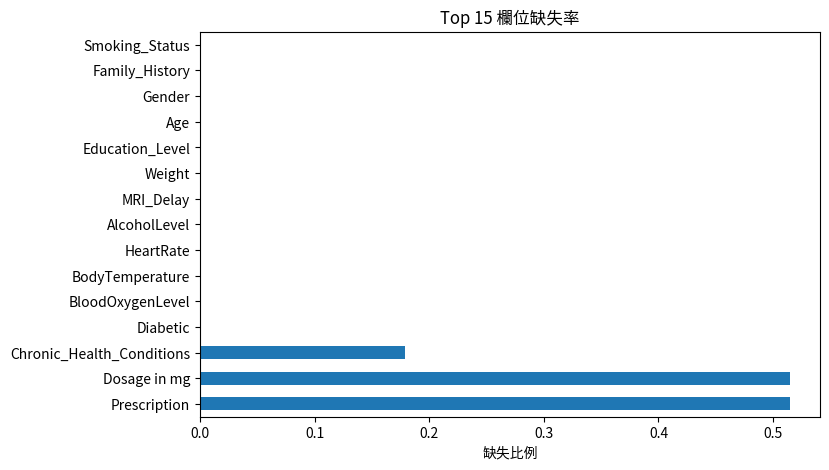

In [ ]:
#  缺失值分析
missing = df.isna().mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
missing.head(15).plot.barh()
plt.title("Top 15 欄位缺失率")
plt.xlabel("缺失比例")
plt.show()

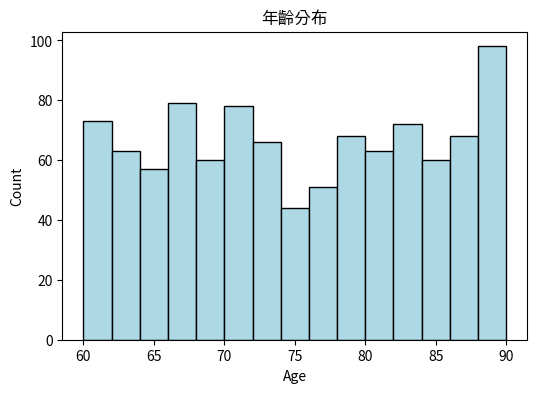

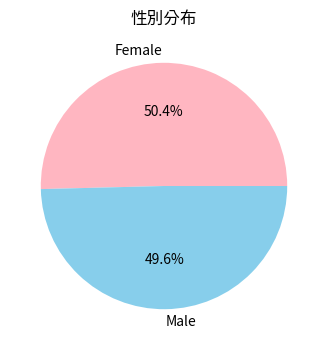

In [ ]:
# 年齡與性別結構分析
# 先將 age/gender 分成兩個欄位
if 'age/gender' in df.columns:
    df[['Age','Gender']] = df['age/gender'].str.split('/', expand=True)
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

plt.figure(figsize=(6,4))
df['Age'].dropna().plot.hist(bins=15, color='lightblue', edgecolor='black')
plt.title('年齡分布')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(4,4))
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#FFB6C1','#87CEEB'])
plt.title('性別分布')
plt.ylabel('')
plt.show()

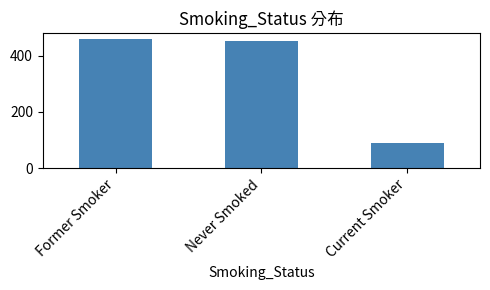

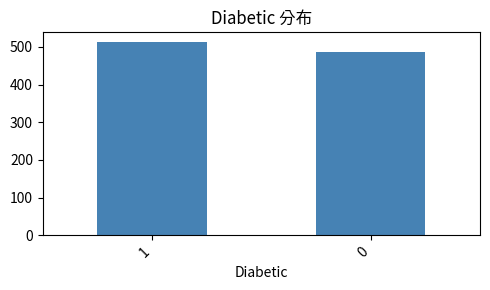

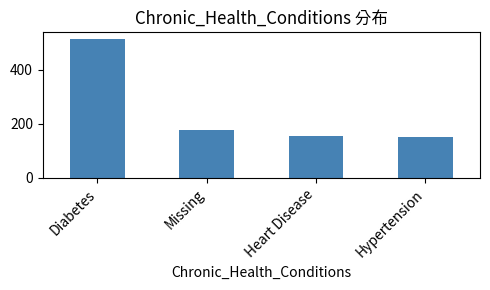

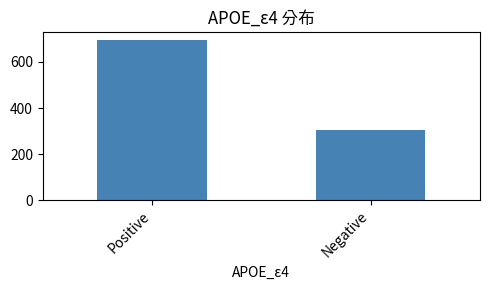

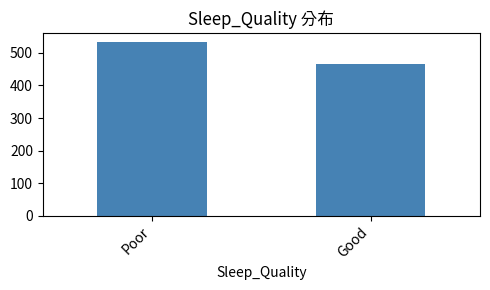

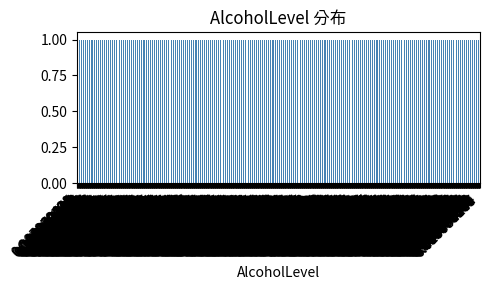

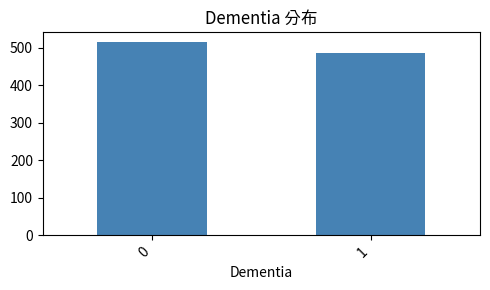

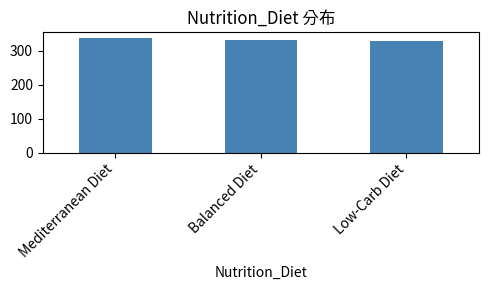

In [ ]:
import matplotlib.pyplot as plt

# 臨床風險因子分布
cols = [
    'Smoking_Status','Diabetic','Chronic_Health_Conditions','APOE_ε4',
    'Sleep_Quality','AlcoholLevel','Dementia','Nutrition_Diet'
]


for c in cols:
    if c in df.columns:
        plt.figure(figsize=(5,3))

        s = df[c].copy()
        # ✅ 把缺失值標出來，避免都變成字串 'nan' 混淆
        s = s.astype("object").where(~s.isna(), other="Missing")

        s.value_counts(dropna=False).plot.bar(color='steelblue')
        plt.title(f'{c} 分布')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


# 3.資料前處理（Data Preprocessing）

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1️⃣ Mapping Dictionaries
# =========================
diet_map = {
    'low-carb diet': 0,
    'balanced diet': 1,
    'mediterranean diet': 2
}
sleep_map = {'poor': 0, 'good': 1}
apoe_map = {'negative': 0, 'positive': 1}

# 慢性病：只有有/沒有（非 nan 都算 1）
health_map = {'nan': 0, 'diabetes': 1, 'heart disease': 1, 'hypertension': 1}

smoke_map = {'never smoked': 0, 'former smoker': 1, 'current smoker': 2}

# =========================
# 2️⃣ Feature Encoding
# =========================
def safe_map(series, mapper):
    s = series.astype("object").str.lower().str.strip()
    s = s.where(~s.isna(), other="nan")
    return s.map(mapper)

if 'Nutrition_Diet' in df.columns:
    df['Nutrition_Diet_num'] = safe_map(df['Nutrition_Diet'], diet_map)

if 'Sleep_Quality' in df.columns:
    df['Sleep_Quality_num'] = safe_map(df['Sleep_Quality'], sleep_map)

if 'APOE_ε4' in df.columns:
    df['APOE_ε4_num'] = safe_map(df['APOE_ε4'], apoe_map)

if 'Chronic_Health_Conditions' in df.columns:
    df['Chronic_Health_Conditions_num'] = safe_map(df['Chronic_Health_Conditions'], health_map)

if 'Smoking_Status' in df.columns:
    df['Smoking_Status_num'] = safe_map(df['Smoking_Status'], smoke_map)

# =========================
# 3️⃣ AlcoholLevel → BAC 分組（0/1/2）
# =========================
if 'AlcoholLevel' in df.columns:
    df['AlcoholLevel'] = pd.to_numeric(df['AlcoholLevel'], errors='coerce')

    def alcohol_bac_group(bac):
        if pd.isna(bac) or bac == 0:
            return 0
        elif bac < 0.08:
            return 1
        else:
            return 2

    df['AlcoholLevel_num'] = df['AlcoholLevel'].apply(alcohol_bac_group)

# =========================
# 4️⃣ Age
# =========================
if 'Age' in df.columns:
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# ==========================================================
# 4.6️⃣ 發炎分組（0123）— 最終統一版本
# 定義：
# 0 = 無發炎風險
# 1 = 1 個發炎風險
# 2 = 2 個發炎風險
# 3 = 3 個發炎風險
#
# 發炎風險來源：
# - 抽菸：Smoking_Status_num == 2（目前抽菸）
# - 慢性病：Chronic_Health_Conditions_num == 1
# - 酒精：AlcoholLevel_num > 1（BAC ≥ 0.08）
# ==========================================================
need_cols = [
    "Smoking_Status_num",
    "Chronic_Health_Conditions_num",
    "AlcoholLevel_num"
]

if all(c in df.columns for c in need_cols):

    smoke_inflam = (
        pd.to_numeric(df["Smoking_Status_num"], errors="coerce").fillna(0) == 2
    ).astype(int)

    chronic_inflam = (
        pd.to_numeric(df["Chronic_Health_Conditions_num"], errors="coerce").fillna(0) == 1
    ).astype(int)

    alcohol_inflam = (
        pd.to_numeric(df["AlcoholLevel_num"], errors="coerce").fillna(0) > 1
    ).astype(int)

    # 0123：同時具備的發炎風險數量
    df["Inflammation_group0123"] = (
        smoke_inflam + chronic_inflam + alcohol_inflam
    )

else:
    df["Inflammation_group0123"] = np.nan


# ==========================================================
# 4.6️⃣ 發炎二元變數（最終修正版，給 Phi Coefficient 用）
# 定義：
# - 抽菸：Smoking_Status_num == 2（目前抽菸）
# - 慢性病：Chronic_Health_Conditions_num == 1
# - 飲酒：AlcoholLevel_num > 1（BAC ≥ 0.08）
# 任一成立 → 1，其餘 → 0
# ==========================================================
need_cols = [
    "Smoking_Status_num",
    "Chronic_Health_Conditions_num",
    "AlcoholLevel_num"
]

if all(c in df.columns for c in need_cols):

    # 目前抽菸者
    smoke_inflam = (
        pd.to_numeric(df["Smoking_Status_num"], errors="coerce").fillna(0) == 2
    )

    # 有慢性病
    chronic_inflam = (
        pd.to_numeric(df["Chronic_Health_Conditions_num"], errors="coerce").fillna(0) == 1
    )

    # 高酒精暴露（BAC ≥ 0.08）
    alcohol_inflam = (
        pd.to_numeric(df["AlcoholLevel_num"], errors="coerce").fillna(0) > 1
    )

    # 任一成立即視為「有發炎風險」
    df["Inflammation_any01"] = (
        smoke_inflam | chronic_inflam | alcohol_inflam
    ).astype(int)

else:
    df["Inflammation_any01"] = np.nan


# 飲食是否「地中海」
if "Nutrition_Diet_num" in df.columns:
    df["Diet_mediterranean01"] = (pd.to_numeric(df["Nutrition_Diet_num"], errors="coerce") == 2).astype(int)
else:
    df["Diet_mediterranean01"] = np.nan

# =========================
# 5️⃣ 定義 feature_cols（你要 ML 用哪些就放哪些）
# - 注意：你說「發炎組跟飲食組也改成0/1」：
#   我這裡是新增 (Inflammation_any01, Diet_mediterranean01) 給 Phi / 或 ML 用
#   012 的 Inflammation_group012 仍保留給後續分層分析，不會誤用
# =========================
feature_cols = [
    'Age',
    'Sleep_Quality_num',
    'APOE_ε4_num',
    'Inflammation_score_w_norm',   # ML 可用（連續）
    'Inflammation_group0123',       # 後續分層分析用（012）
    'Inflammation_any01',          # ✅ Phi / 二元版本
    'Diet_mediterranean01',        # ✅ Phi / 二元版本
    'Dementia'
]
feature_cols = [c for c in feature_cols if c in df.columns]

print("✅ 使用中的 feature_cols：")
print(feature_cols)

print("\n轉換後資料預覽：")
display(df[feature_cols].head())

print("\n缺失值檢查：")
display(df[feature_cols].isnull().sum())

print("\n[Inflammation_any01 分布]")
display(df["Inflammation_any01"].value_counts(dropna=False))

print("\n[Diet_mediterranean01 分布]")
display(df["Diet_mediterranean01"].value_counts(dropna=False))

print("\n[Inflammation_group0123 分布]")
display(df["Inflammation_group0123"].value_counts(dropna=False).sort_index())


✅ 使用中的 feature_cols：
['Age', 'Sleep_Quality_num', 'APOE_ε4_num', 'Inflammation_group0123', 'Inflammation_any01', 'Diet_mediterranean01', 'Dementia']

轉換後資料預覽：


,Age,Sleep_Quality_num,APOE_ε4_num,Inflammation_group0123,Inflammation_any01,Diet_mediterranean01,Dementia
0,60,0,0,3,1,0,0
1,61,0,1,1,1,0,1
2,69,0,0,1,1,1,0
3,78,0,0,2,1,0,1
4,77,1,1,2,1,0,1



缺失值檢查：


,0
Age,0
Sleep_Quality_num,0
APOE_ε4_num,0
Inflammation_group0123,0
Inflammation_any01,0
Diet_mediterranean01,0
Dementia,0



[Inflammation_any01 分布]


,count
Inflammation_any01,
1,948
0,52



[Diet_mediterranean01 分布]


,count
Diet_mediterranean01,
0,662
1,338



[Inflammation_group0123 分布]


,count
Inflammation_group0123,
0,52
1,431
2,478
3,39


In [ ]:
# # 數值欄位敘述統計
num_cols = df.select_dtypes(include=[np.number]).columns

print("\n[數值欄位統計]")
if len(num_cols) > 0:
    display(df[num_cols].describe().T)
else:
    print("⚠️ 沒有偵測到數值欄位（可能所有欄位都是文字或分類型資料）")

print("\n[模型使用之數值欄位統計]")
display(df[feature_cols].describe().T)
print("\n🧪 特徵版本檢查：")
print("feature_cols =", feature_cols)
print("df.columns 中 *_num 欄位 =", [c for c in df.columns if c.endswith("_num")])
print("\n[Inflammation_score_norm 分布（前10）]")
if "Inflammation_score_norm" in df.columns:
    display(df["Inflammation_score_norm"].value_counts(dropna=False).head(10))




[數值欄位統計]


,count,mean,std,min,25%,50%,75%,max
Diabetic,1000.0,0.513000,0.500081,0.000000,0.000000,1.000000,1.000000,1.000000
AlcoholLevel,1000.0,0.098429,0.058715,0.000414,0.045505,0.098235,0.151840,0.199866
HeartRate,1000.0,79.383000,12.107556,60.000000,68.000000,79.000000,90.000000,100.000000
BloodOxygenLevel,1000.0,95.226051,2.929262,90.010677,92.875017,95.390420,97.785111,99.999230
BodyTemperature,1000.0,36.761513,0.431701,36.002108,36.395363,36.784319,37.126655,37.496809
Weight,1000.0,74.321326,14.463765,50.069731,61.387339,74.149204,87.024034,99.982722
MRI_Delay,1000.0,30.103568,16.862170,0.094684,16.237371,29.577194,44.176723,59.957599
Dosage in mg,485.0,9.213402,6.493188,1.500000,4.000000,8.000000,12.000000,23.000000
Age,1000.0,74.908000,9.095068,60.000000,67.000000,75.000000,83.000000,90.000000
Cognitive_Test_Scores,1000.0,6.383000,3.180633,0.000000,4.000000,8.000000,9.000000,10.000000



[模型使用之數值欄位統計]


,count,mean,std,min,25%,50%,75%,max
Age,1000.0,74.908,9.095068,60.0,67.0,75.0,83.0,90.0
Sleep_Quality_num,1000.0,0.466,0.499092,0.0,0.0,0.0,1.0,1.0
APOE_ε4_num,1000.0,0.694,0.461060,0.0,0.0,1.0,1.0,1.0
Inflammation_group0123,1000.0,1.504,0.657584,0.0,1.0,2.0,2.0,3.0
Inflammation_any01,1000.0,0.948,0.222138,0.0,1.0,1.0,1.0,1.0
Diet_mediterranean01,1000.0,0.338,0.473265,0.0,0.0,0.0,1.0,1.0
Dementia,1000.0,0.485,0.500025,0.0,0.0,0.0,1.0,1.0



🧪 特徵版本檢查：
feature_cols = ['Age', 'Sleep_Quality_num', 'APOE_ε4_num', 'Inflammation_group0123', 'Inflammation_any01', 'Diet_mediterranean01', 'Dementia']
df.columns 中 *_num 欄位 = ['Nutrition_Diet_num', 'Sleep_Quality_num', 'APOE_ε4_num', 'Chronic_Health_Conditions_num', 'Smoking_Status_num', 'AlcoholLevel_num']

[Inflammation_score_norm 分布（前10）]


## [EDA - 相關性分析矩陣]

從相關矩陣可以觀察到，臨床特徵（例如年齡、糖尿病、住院史等）與多重抗藥性（MDR）之間的線性關係並不強。  
然而，這並不代表這些變數對抗藥性沒有影響。實際上，抗藥性往往是多個臨床與微生物因子交互作用的結果。

因此，我們會採用能處理**非線性關係**的機器學習模型（例如 **Random Forest**、**XGBoost** 等），  
以捕捉這些複雜的潛在關聯，進一步提升預測能力。



[Correlation Matrix]


,Age,Sleep_Quality_num,APOE_ε4_num,Inflammation_group0123,Inflammation_any01,Diet_mediterranean01,Dementia
Age,1.000000,-0.003336,-0.017701,-0.024040,-0.008811,0.076998,-0.062154
Sleep_Quality_num,-0.003336,1.000000,-0.006107,-0.011785,0.011123,-0.006391,-0.020096
APOE_ε4_num,-0.017701,-0.006107,1.000000,-0.055388,-0.018687,0.015726,0.427292
Inflammation_group0123,-0.024040,-0.011785,-0.055388,1.000000,0.535934,0.005301,-0.156600
Inflammation_any01,-0.008811,0.011123,-0.018687,0.535934,1.000000,-0.023080,-0.061101
Diet_mediterranean01,0.076998,-0.006391,0.015726,0.005301,-0.023080,1.000000,0.021446
Dementia,-0.062154,-0.020096,0.427292,-0.156600,-0.061101,0.021446,1.000000


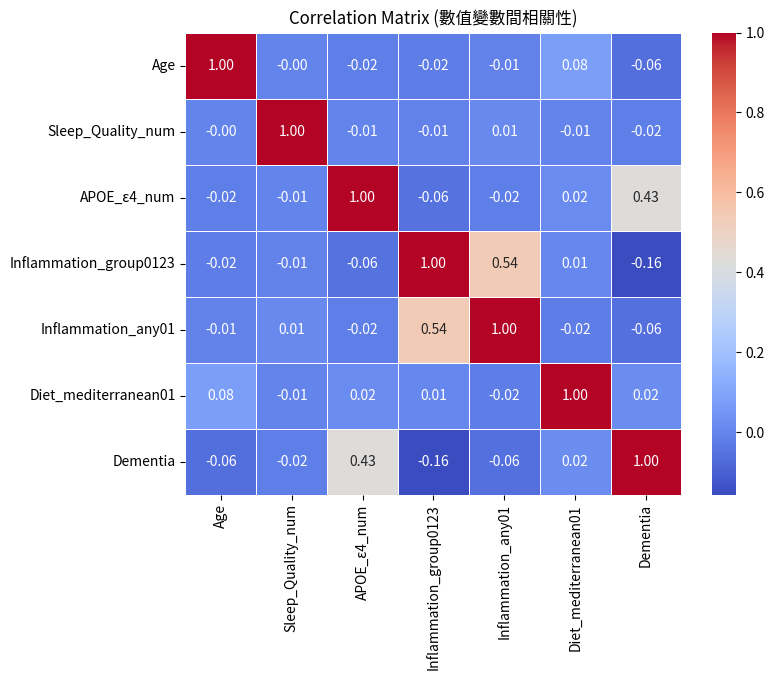


[與 Dementia 最相關的前 5 名]


,Dementia
Dementia,1.000000
APOE_ε4_num,0.427292
Diet_mediterranean01,0.021446
Sleep_Quality_num,-0.020096
Inflammation_any01,-0.061101
Age,-0.062154



[與 Dementia 最不相關的 5 名]


,Dementia
Diet_mediterranean01,0.021446
Sleep_Quality_num,-0.020096
Inflammation_any01,-0.061101
Age,-0.062154
Inflammation_group0123,-0.156600


In [ ]:
## [EDA - 相關性分析矩陣]
import seaborn as sns

# 3️⃣ 建立相關係數矩陣，使用 feature_cols，其中已包含 Dementia
corr_df = df[feature_cols].corr(numeric_only=True)

# 4️⃣ 顯示矩陣
print("\n[Correlation Matrix]")
display(corr_df)

# 5️⃣ 熱圖視覺化
plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (數值變數間相關性)")
plt.show()

# 6️⃣ 顯示與 Dementia 的相關性排序
if 'Dementia' in corr_df.columns:
    corr_to_target = corr_df['Dementia'].sort_values(ascending=False)

    print("\n[與 Dementia 最相關的前 5 名]")
    display(corr_to_target.head(6))  # 含 Dementia 本身

    print("\n[與 Dementia 最不相關的 5 名]")
    display(corr_to_target.tail(5))


🧪 用於 Phi coefficient 的變數：
['Diet_mediterranean01', 'Sleep_good01', 'Inflammation_any01', 'APOE_ε4_num']

[Phi coefficient with Dementia]


,Phi_coefficient
Diet_mediterranean01,0.021446
Sleep_good01,0.020096
Inflammation_any01,0.061101
APOE_ε4_num,0.427292


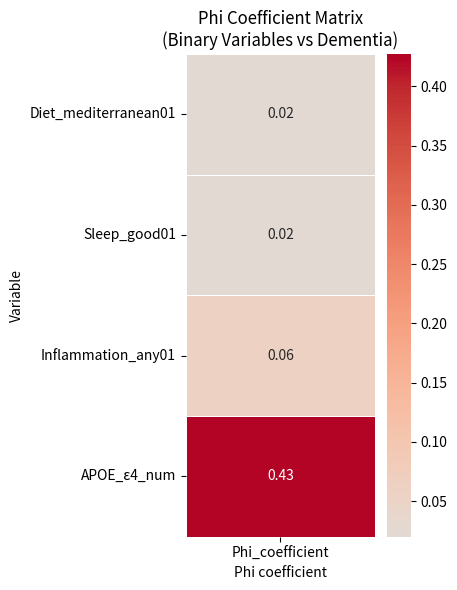

In [ ]:
## [EDA - Phi Coefficient Heatmap (Binary Association with Dementia)]
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# =========================
# 1️⃣ Phi coefficient 函數
# =========================
def phi_coefficient(x, y):
    """
    x, y: 兩個二元變數（0/1）
    回傳 Phi coefficient
    """
    table = pd.crosstab(x, y)
    if table.shape != (2, 2):
        return np.nan
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.values.sum()
    return np.sqrt(chi2 / n)

# =========================
# 2️⃣ 指定要做 Phi 的「二元變數」
# （你前面已經整理好的版本）
# =========================
phi_vars = [
    "Diet_mediterranean01",   # 地中海飲食（1=是）
    "Sleep_good01",           # 睡眠品質好（1=好）
    "Inflammation_any01",     # 發炎任一因子（1=有）
    "APOE_ε4_num"             # APOE ε4（1=有）
]

# 保險：只留下 df 裡真的存在的欄位
phi_vars = [c for c in phi_vars if c in df.columns]

print("🧪 用於 Phi coefficient 的變數：")
print(phi_vars)

# =========================
# 3️⃣ 計算 Phi coefficient（vs Dementia）
# =========================
phi_results = {}
for c in phi_vars:
    phi_results[c] = phi_coefficient(df[c], df["Dementia"])

phi_df = (
    pd.Series(phi_results, name="Phi_coefficient")
    .to_frame()
)

print("\n[Phi coefficient with Dementia]")
display(phi_df)

# =========================
# 4️⃣ Heatmap 視覺化（總覽版）
# =========================
plt.figure(figsize=(4.5, 6))
sns.heatmap(
    phi_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar=True
)
plt.title("Phi Coefficient Matrix\n(Binary Variables vs Dementia)")
plt.ylabel("Variable")
plt.xlabel("Phi coefficient")
plt.tight_layout()
plt.show()


# 4.特徵工程（Feature Engineering）

*   特徵選擇、轉換、降維或新特徵生成

*   提升模型表現與可解釋性


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

def build_features_idempotent(df, target_col='Dementia', feature_mode="research5"):
    """
    失智研究版（保留原版 idempotent / 編碼 / 補值精神）
    feature_mode:
      - "research5": ✅ 只用你研究核心：Age + Diet + Sleep + APOE + Inflammation_score_w_norm
      - "core7": 7 個核心特徵（Age + *_num；含抽菸/喝酒/慢性病）
      - "core8": core7 + Inflammation_score_w_norm（會同時吃分數+三原始欄，不是你現在要的）
      - "core9": core8 + Inflammation_group012
      - "full14": 14 特徵版本（含生命徵象/檢測等）
    """
    df = df.copy()

    # 0) 清掉 MDR 模板可能留下來的衍生欄位（避免誤入特徵）
    cols_to_drop = [
        c for c in df.columns
        if c.endswith("_AST") or c.endswith("_res") or c.startswith("fam_") or c == "num_res_families"
    ]
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    # ✅ 1) 你要的研究用：只用發炎分數，不用抽菸/喝酒/慢性病原始欄
    research5 = [
        'Age',
        'Nutrition_Diet_num',
        'Sleep_Quality_num',
        'APOE_ε4_num',
        'Inflammation_score_w_norm'
    ]

    # 原本的（保留）
    core7 = [
        'Age',
        'Nutrition_Diet_num',
        'Sleep_Quality_num',
        'APOE_ε4_num',
        'Chronic_Health_Conditions_num',
        'Smoking_Status_num',
        'AlcoholLevel_num',
    ]

    core8 = core7 + ['Inflammation_score_w_norm']
    core9 = core8 + ['Inflammation_group012']

    full14 = [
        'Age',
        'AlcoholLevel_num',
        'HeartRate',
        'BloodOxygenLevel',
        'BodyTemperature',
        'Weight',
        'MRI_Delay',
        'Dosage in mg',
        'Cognitive_Test_Scores',
        'Nutrition_Diet_num',
        'Sleep_Quality_num',
        'APOE_ε4_num',
        'Chronic_Health_Conditions_num',
        'Smoking_Status_num'
    ]

    if feature_mode == "research5":
        features = research5
    elif feature_mode == "core7":
        features = core7
    elif feature_mode == "core8":
        features = core8
    elif feature_mode == "core9":
        features = core9
    elif feature_mode == "full14":
        features = full14
    else:
        raise ValueError("feature_mode must be 'research5','core7','core8','core9', or 'full14'")

    # 只保留 df 中真的存在的欄位
    features = [f for f in features if f in df.columns]

    # 2) 產生 X / y
    X = df[features].copy()
    y = df[target_col].copy() if target_col in df.columns else None

    # 3) 類別編碼（理論上你 *_num 都是數值；這是保險）
    for col in X.columns:
        if X[col].dtype == object:
            X[col] = X[col].astype(str).fillna("NA")
            X[col] = LabelEncoder().fit_transform(X[col])

    # 小保險：全部轉 numeric
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    # 4) 缺值補值（中位數）
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)
    X = pd.DataFrame(X_imputed, columns=features)

    return X, y, features, imputer, df


In [ ]:
X, y, feature_names, imputer, df_processed = build_features_idempotent(
    df, target_col='Dementia', feature_mode="research5"
)

print("🎯 X 形狀：", X.shape)
print("✅ 使用特徵數：", len(feature_names))
print("🧾 特徵清單:", feature_names)


🎯 X 形狀： (1000, 4)
✅ 使用特徵數： 4
🧾 特徵清單: ['Age', 'Nutrition_Diet_num', 'Sleep_Quality_num', 'APOE_ε4_num']


## Gemini建議：標準化後

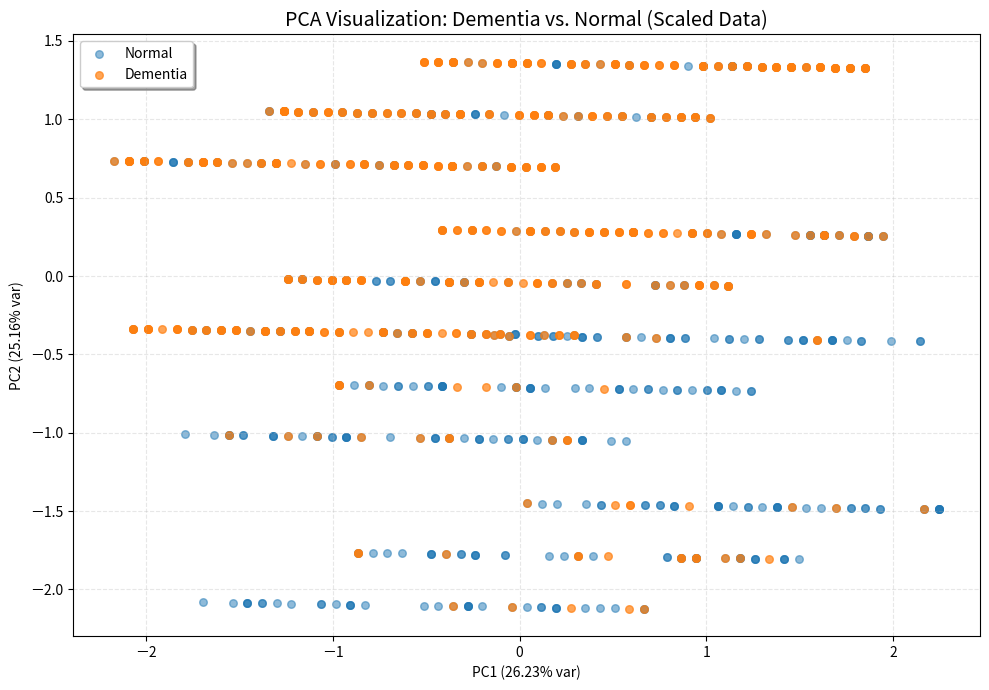

------------------------------
各主成分解釋變異比例：
PC1: 26.23%
PC2: 25.16%
累積解釋變異：51.39%
------------------------------
影響第一主成分 (PC1) 最大的前 5 個特徵：
Age: 0.7146 (+) (loading=0.7146)
Nutrition_Diet_num: 0.6759 (+) (loading=0.6759)
APOE_ε4_num: 0.1734 (-) (loading=-0.1734)
Sleep_Quality_num: 0.0495 (+) (loading=0.0495)


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 使用前一段特徵工程產生的 X, y（未 Oversample）
X_pca_input = X.copy()
y_pca_input = pd.to_numeric(y.copy(), errors='coerce')  # 保險轉 0/1

# 1️⃣ 資料標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_input)

# 2️⃣ PCA（2D）
pca = PCA(n_components=2, random_state=42)
X_pca_2d = pca.fit_transform(X_scaled)

# 3️⃣ 繪圖
plt.figure(figsize=(10, 7))

mask0 = (y_pca_input == 0)
mask1 = (y_pca_input == 1)

plt.scatter(X_pca_2d[mask0, 0], X_pca_2d[mask0, 1], label='Normal', alpha=0.5, s=30)
plt.scatter(X_pca_2d[mask1, 0], X_pca_2d[mask1, 1], label='Dementia', alpha=0.7, s=30)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} var)")
plt.title("PCA Visualization: Dementia vs. Normal (Scaled Data)", fontsize=14, fontweight='bold')
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 4️⃣ 解釋變異
print("-" * 30)
print("各主成分解釋變異比例：")
for i, v in enumerate(pca.explained_variance_ratio_, 1):
    print(f"PC{i}: {v:.2%}")
print(f"累積解釋變異：{pca.explained_variance_ratio_.sum():.2%}")
print("-" * 30)

# 5️⃣ PC1 loading（前 5）
pc1_loads = pd.Series(pca.components_[0], index=X_pca_input.columns)
top_features = pc1_loads.abs().sort_values(ascending=False).head(5)

print("影響第一主成分 (PC1) 最大的前 5 個特徵：")
for feat in top_features.index:
    val = pc1_loads[feat]
    direction = "(+)" if val > 0 else "(-)"
    print(f"{feat}: {abs(val):.4f} {direction} (loading={val:.4f})")


In [ ]:
#df['PC1'], df['PC2'] = X_pca_2d[:,0], X_pca_2d[:,1] #可以選擇要不要將PCA後的值放到特徵裡面



#5.資料拆分與交叉驗證（Data Splitting & Cross-Validation）

* 首先使用 `train_test_split()` 將資料切分為 80% 的訓練集與 20% 的測試集，並採用 `stratify=y` 的分層抽樣方式，確保訓練與測試集中
「Non-MDR」與「MDR」兩類的比例一致。



* 由於資料中 MDR（多重抗藥）為少數類別，屬於類別不平衡問題，
因此在交叉驗證前，針對訓練集使用 **`RandomOverSampler`** 進行過採樣，
讓正負類的樣本數量更為平衡，以避免模型偏向預測多數類（Non-MDR）。


* 接著，在訓練資料上進行 **5 折分層交叉驗證（5-Fold Stratified Cross-Validation）**，讓每個模型都能在不同資料子集上被訓練與驗證，提升模型泛化能力。



In [ ]:
# [資料切分]：分層抽樣，固定隨機種子
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)
Xtr.shape, Xte.shape, ytr.shape, yte.shape  #查看拆分資料集過後的資料量

((800, 4), (200, 4), (800,), (200,))

Train: (800, 4), Test: (200, 4)


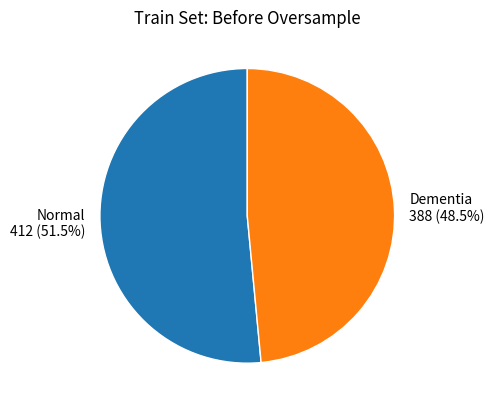

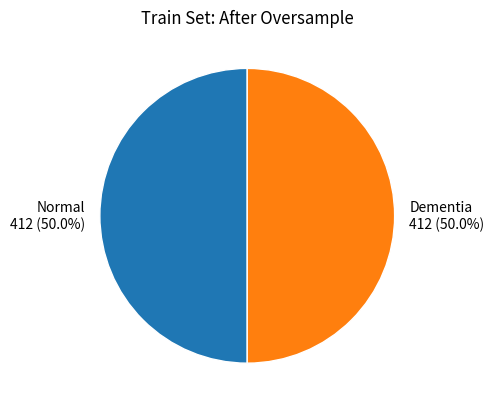

✅ 注意：Xtr / ytr 保持『未 oversample』版本，供 CV 與模型選擇使用


In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt

# 分層切割（唯一一次）
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {Xtr.shape}, Test: {Xte.shape}")

# -------- Oversample 前（檢查用）--------
label_map = {0: 'Normal', 1: 'Dementia'}
counts_before = ytr.map(label_map).value_counts().reindex(['Normal','Dementia'])
props_before = counts_before / counts_before.sum()

plt.figure(figsize=(5,5))
plt.pie(
    counts_before,
    labels=[f"{lbl}\n{cnt} ({pct:.1f}%)"
            for lbl, cnt, pct in zip(counts_before.index, counts_before, props_before*100)],
    startangle=90, wedgeprops={'edgecolor':'white'}
)
plt.title("Train Set: Before Oversample")
plt.tight_layout()
plt.show()

# -------- Oversample 後（只拿來看分布）--------
ros = RandomOverSampler(random_state=42)
Xtr_over, ytr_over = ros.fit_resample(Xtr, ytr)

counts_after = ytr_over.map(label_map).value_counts().reindex(['Normal','Dementia'])
props_after = counts_after / counts_after.sum()

plt.figure(figsize=(5,5))
plt.pie(
    counts_after,
    labels=[f"{lbl}\n{cnt} ({pct:.1f}%)"
            for lbl, cnt, pct in zip(counts_after.index, counts_after, props_after*100)],
    startangle=90, wedgeprops={'edgecolor':'white'}
)
plt.title("Train Set: After Oversample")
plt.tight_layout()
plt.show()

print("✅ 注意：Xtr / ytr 保持『未 oversample』版本，供 CV 與模型選擇使用")


In [ ]:
from sklearn.model_selection import StratifiedKFold

# 分層 5 折交叉驗證
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("✅ Stratified 5-Fold CV 已建立")


✅ Stratified 5-Fold CV 已建立


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

pipe = Pipeline(steps=[
    ("ros", RandomOverSampler(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42))
])

scores = cross_val_score(
    pipe,
    Xtr, ytr,          # ❗ 原始 train（未 oversample）
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print("5-Fold CV AUC scores:", scores)
print("Mean AUC:", scores.mean())


5-Fold CV AUC scores: [0.63586617 0.6402439  0.66400876 0.68518229 0.67618526]
Mean AUC: 0.6602972744759403


# 6.模型選擇（Model Selection）

使用羅吉斯回歸、隨機森林和ExtraTrees來進行建模，當中可以調整超參數來調整
目前示範的三種基礎模型：

1. 羅吉斯回歸（Logistic Regression）



  *   最簡單的二元分類模型，能提供清楚的特徵權重解釋。


  *   適合初學者了解「輸入特徵對結果的線性影響」。



2. 隨機森林（Random Forest）

* 以「多棵決策樹」組成的集成模型（Ensemble Model），能捕捉非線性關係。

* 不需要太多資料前處理，抗雜訊能力強，是醫學類資料分析的常見基線模型。

3. 極端隨機森林（ExtraTrees Classifier）

* 與隨機森林類似，但在分裂節點時更隨機。

* 通常能更快訓練、略減過擬合，適合當作隨機森林的對照模型。


In [ ]:
# ⚠️ 首次使用時請先安裝外部套件（在 Colab 執行以下指令一次即可）
!pip -q install xgboost lightgbm catboost

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.4 MB/s eta 0:00:00


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

clfs = {
    # Logistic Regression：線性模型，可作為基準線
    "LogReg": LogisticRegression(
        max_iter=400,
        random_state=42,
        solver="liblinear"   # ✅ 小修：常見且穩定
    ),

    # Random Forest：隨機森林
    "RF": RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        n_jobs=-1            # ✅ 小修：加速
    ),

    # Extra Trees：極端隨機樹
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=150,
        random_state=42,
        n_jobs=-1            # ✅ 小修：加速
    ),

    # --- 進階梯度提升 ---
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        eval_metric="logloss",  # ✅ 小修：避免 warning
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=-1,
        random_state=42,
        verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=6,
        random_seed=42,
        verbose=0
    )
}


# 7.模型訓練與優化（Model Training & Optimization）
可以調整模型的超參數後來交叉驗證時，找出最好的超參數

In [ ]:
# [分層 5 折交叉驗證 - 正確版：ROS 必須在每折訓練集內]
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

cv_rows = []

print("開始 5-Fold Stratified CV (with RandomOverSampler inside CV)...\n")

for name, clf in tqdm(clfs.items(), desc="模型進度", unit="model"):
    # ✅ Pipeline：每一折的 train 才 oversample，避免洩漏
    pipe = Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=42)),
        ("clf", clf)
    ])

    # Accuracy
    acc_scores = cross_val_score(pipe, Xtr, ytr, cv=skf, scoring='accuracy', n_jobs=-1)

    # F1（不平衡時更有參考價值）
    f1_scores  = cross_val_score(pipe, Xtr, ytr, cv=skf, scoring='f1', n_jobs=-1)

    # ROC AUC（盡可能計算）
    try:
        auc_scores = cross_val_score(pipe, Xtr, ytr, cv=skf, scoring='roc_auc', n_jobs=-1)
        auc_mean, auc_std = auc_scores.mean(), auc_scores.std()
    except Exception:
        auc_scores = None
        auc_mean, auc_std = np.nan, np.nan

    cv_rows.append({
        "Model": name,
        "CV Acc (mean±std)": f"{acc_scores.mean():.3f} ± {acc_scores.std():.3f}",
        "CV F1  (mean±std)": f"{f1_scores.mean():.3f} ± {f1_scores.std():.3f}",
        "CV AUC (mean±std)": f"{auc_mean:.3f} ± {auc_std:.3f}" if not np.isnan(auc_mean) else "NA",

        # 方便排序 / 分析的 float 欄位
        "Acc_mean": float(acc_scores.mean()),
        "F1_mean": float(f1_scores.mean()),
        "AUC_mean": float(auc_mean) if not np.isnan(auc_mean) else np.nan
    })

cv_table = pd.DataFrame(cv_rows).set_index("Model")

print("\n【5-Fold Stratified CV on TRAIN (ROS inside CV)】")
display(cv_table.sort_values(by=["AUC_mean", "F1_mean", "Acc_mean"], ascending=False))


開始 5-Fold Stratified CV (with RandomOverSampler inside CV)...



模型進度: 100%|██████████| 6/6 [00:37<00:00,  6.24s/model]


【5-Fold Stratified CV on TRAIN (ROS inside CV)】


,CV Acc (mean±std),CV F1 (mean±std),CV AUC (mean±std),Acc_mean,F1_mean,AUC_mean
Model,,,,,,
LogReg,0.694 ± 0.023,0.740 ± 0.020,0.712 ± 0.034,0.69375,0.740107,0.711724
LightGBM,0.659 ± 0.032,0.665 ± 0.036,0.691 ± 0.031,0.65875,0.665090,0.690654
XGBoost,0.636 ± 0.031,0.642 ± 0.038,0.681 ± 0.026,0.63625,0.641938,0.681020
CatBoost,0.639 ± 0.034,0.646 ± 0.034,0.681 ± 0.025,0.63875,0.646057,0.680550
RF,0.629 ± 0.022,0.627 ± 0.023,0.661 ± 0.020,0.62875,0.627017,0.661158
ExtraTrees,0.613 ± 0.021,0.580 ± 0.026,0.641 ± 0.023,0.61250,0.580432,0.640967


#8.模型測試與評估（Model Testing & Evaluation）


*   用測試集驗證最終模型的準確率、召回率、F1-score、AUC 等指標
*   檢查是否過擬合或偏差太高




Testing models:   0%|          | 0/6 [00:00<?, ?model/s]

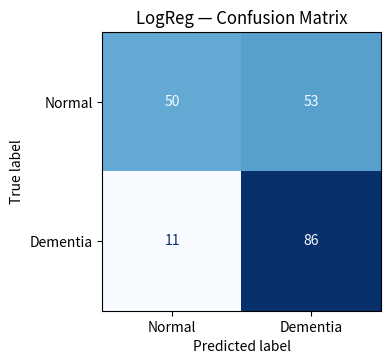


LogReg — Test Acc 0.680  Test F1 0.729
              precision    recall  f1-score   support

           0       0.82      0.49      0.61       103
           1       0.62      0.89      0.73        97

    accuracy                           0.68       200
   macro avg       0.72      0.69      0.67       200
weighted avg       0.72      0.68      0.67       200



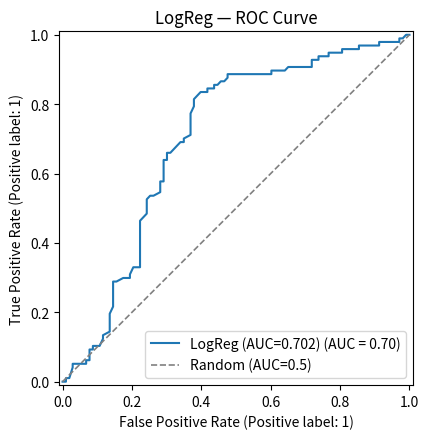

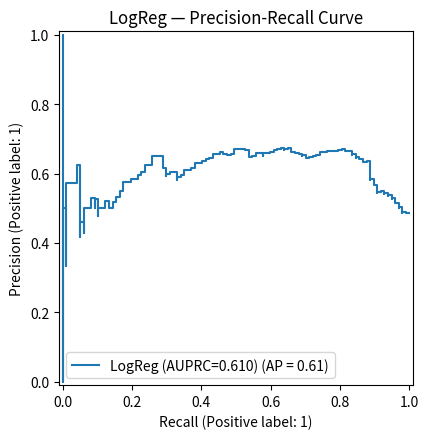

Testing models:  17%|█▋        | 1/6 [00:01<00:05,  1.00s/model]

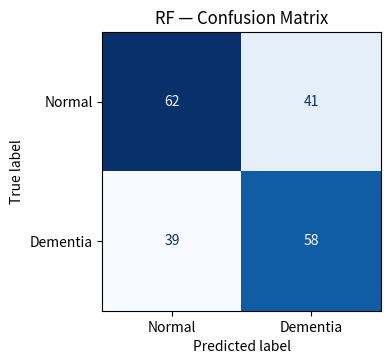


RF — Test Acc 0.600  Test F1 0.592
              precision    recall  f1-score   support

           0       0.61      0.60      0.61       103
           1       0.59      0.60      0.59        97

    accuracy                           0.60       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.60      0.60      0.60       200



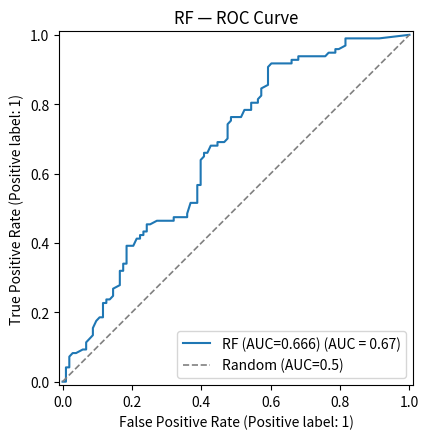

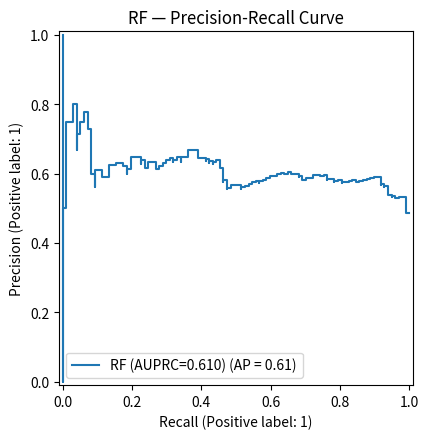

Testing models:  33%|███▎      | 2/6 [00:02<00:04,  1.24s/model]

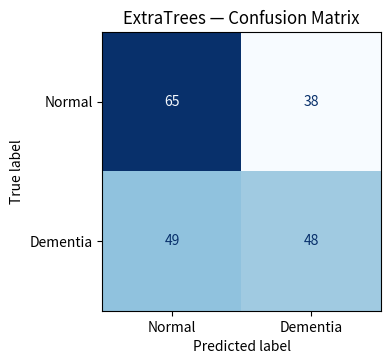


ExtraTrees — Test Acc 0.565  Test F1 0.525
              precision    recall  f1-score   support

           0       0.57      0.63      0.60       103
           1       0.56      0.49      0.52        97

    accuracy                           0.56       200
   macro avg       0.56      0.56      0.56       200
weighted avg       0.56      0.56      0.56       200



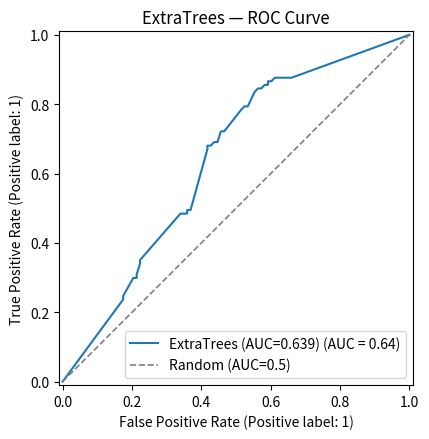

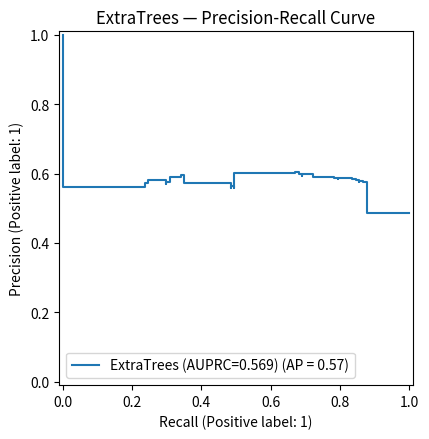

Testing models:  50%|█████     | 3/6 [00:04<00:05,  1.74s/model]

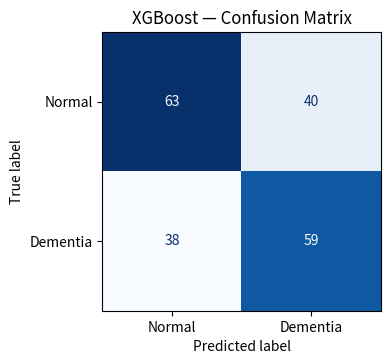


XGBoost — Test Acc 0.610  Test F1 0.602
              precision    recall  f1-score   support

           0       0.62      0.61      0.62       103
           1       0.60      0.61      0.60        97

    accuracy                           0.61       200
   macro avg       0.61      0.61      0.61       200
weighted avg       0.61      0.61      0.61       200



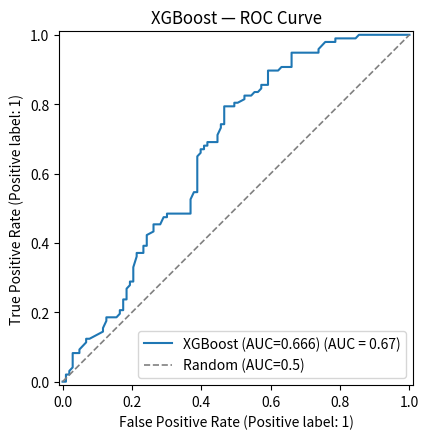

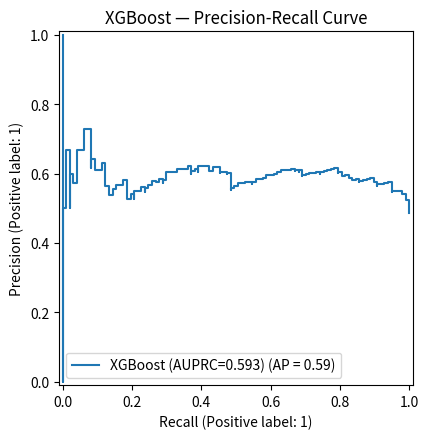

Testing models:  67%|██████▋   | 4/6 [00:08<00:04,  2.35s/model]

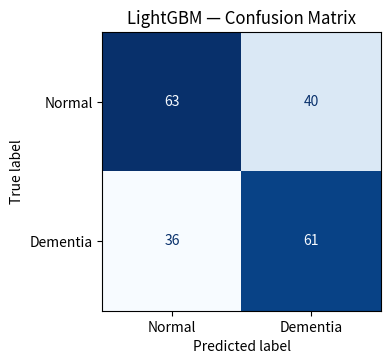


LightGBM — Test Acc 0.620  Test F1 0.616
              precision    recall  f1-score   support

           0       0.64      0.61      0.62       103
           1       0.60      0.63      0.62        97

    accuracy                           0.62       200
   macro avg       0.62      0.62      0.62       200
weighted avg       0.62      0.62      0.62       200



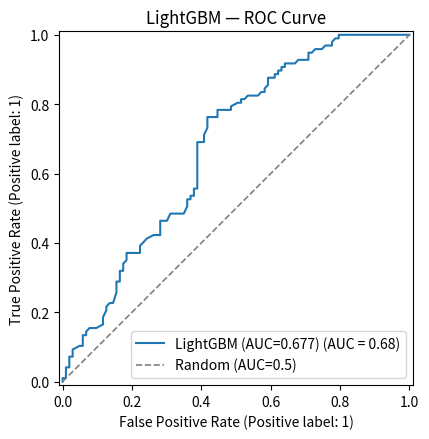

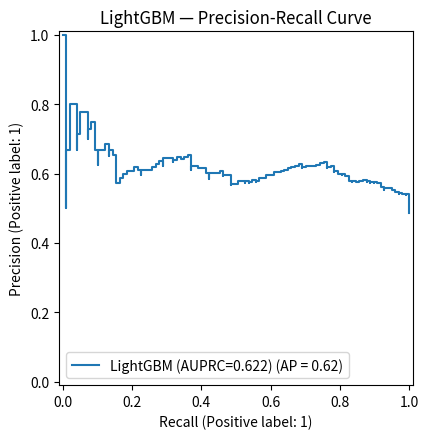

Testing models:  83%|████████▎ | 5/6 [00:09<00:01,  1.92s/model]

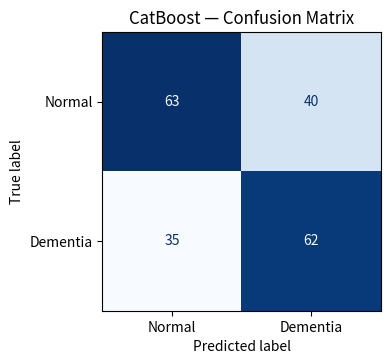


CatBoost — Test Acc 0.625  Test F1 0.623
              precision    recall  f1-score   support

           0       0.64      0.61      0.63       103
           1       0.61      0.64      0.62        97

    accuracy                           0.62       200
   macro avg       0.63      0.63      0.62       200
weighted avg       0.63      0.62      0.63       200



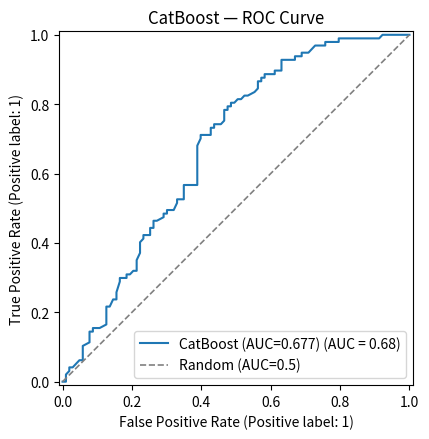

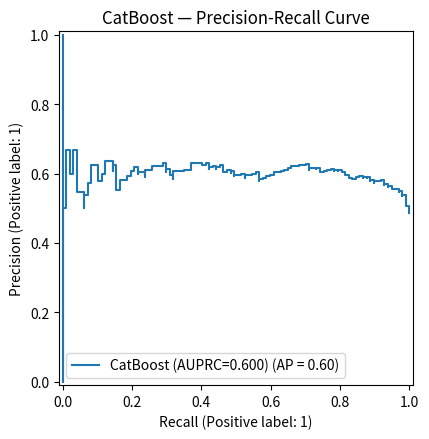

Testing models: 100%|██████████| 6/6 [00:11<00:00,  1.84s/model]


In [ ]:
# 匯入所需模組
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay,
    average_precision_score, PrecisionRecallDisplay,
    classification_report, accuracy_score, f1_score
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

# 儲存各模型評估結果
y_scores = {}
model_auc = {}
model_auprc = {}
model_f1 = {}
trained_models = {}

# ---------------------------
# 模型訓練 + 評估 + 視覺化（期末考：Xte/yte 不可動）
# ✅ ROS 只套在訓練資料（透過 Pipeline）
# ---------------------------
for name, clf in tqdm(clfs.items(), desc="Testing models", unit="model"):
    pipe = Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=42)),
        ("clf", clf)
    ])

    # 訓練：只看訓練集（ROS 在 pipeline 內）
    pipe.fit(Xtr, ytr)

    # 預測：測試集完全不做 ROS
    yp = pipe.predict(Xte)

    # 取得連續分數（供 ROC / PRC 使用）
    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(Xte)[:, 1]
    elif hasattr(pipe, "decision_function"):
        y_score = pipe.decision_function(Xte)
    else:
        y_score = None

    trained_models[name] = pipe  # ✅ 存整條 pipeline，部署不會漏掉 ROS

    # 混淆矩陣
    cm = confusion_matrix(yte, yp, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Dementia'])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # 指標計算
    acc = accuracy_score(yte, yp)
    f1 = f1_score(yte, yp, zero_division=0)
    model_f1[name] = f1

    print(f"\n{name} — Test Acc {acc:.3f}  Test F1 {f1:.3f}")
    print(classification_report(yte, yp, zero_division=0))

    # ROC / PRC
    if y_score is not None:
        # AUROC
        auc = roc_auc_score(yte, y_score)
        model_auc[name] = auc

        fig, ax = plt.subplots(figsize=(5.5, 4.5))
        RocCurveDisplay.from_predictions(yte, y_score, ax=ax, name=f"{name} (AUC={auc:.3f})")
        ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1.2, label='Random (AUC=0.5)')
        ax.set_title(f"{name} — ROC Curve")
        ax.legend(loc="lower right")
        plt.tight_layout()
        plt.show()

        # AUPRC
        auprc = average_precision_score(yte, y_score)
        model_auprc[name] = auprc

        fig, ax = plt.subplots(figsize=(5.5, 4.5))
        PrecisionRecallDisplay.from_predictions(yte, y_score, ax=ax, name=f"{name} (AUPRC={auprc:.3f})")
        ax.set_title(f"{name} — Precision-Recall Curve")
        ax.legend(loc="lower left")
        plt.tight_layout()
        plt.show()

        y_scores[name] = y_score
    else:
        print(f"[{name}] 無法繪製 ROC 或 PRC（模型不提供連續分數）。")


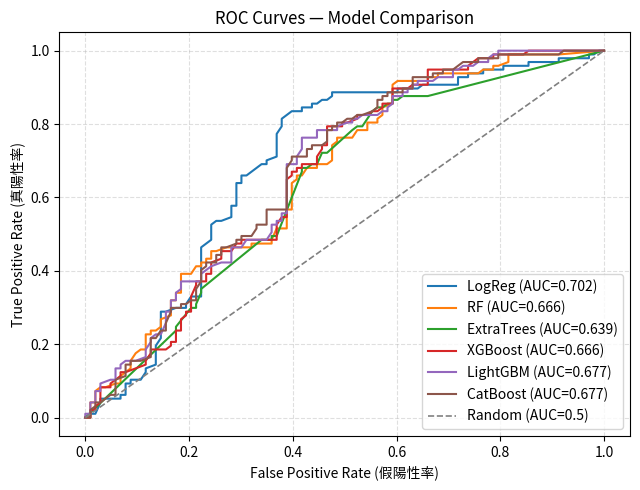

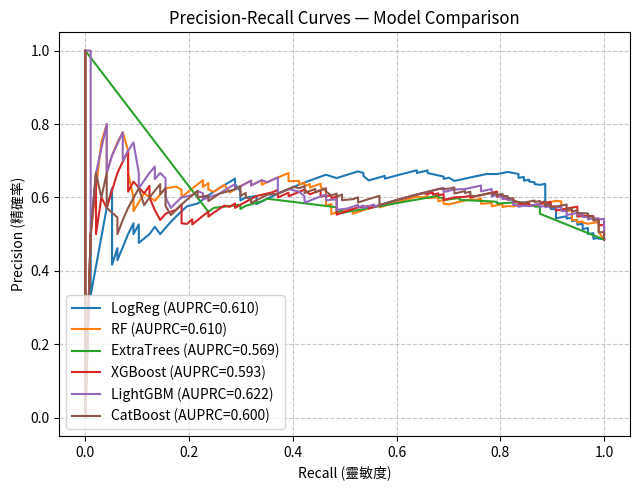

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 多模型 ROC 對照圖（比較各模型辨識能力）
# -------------------------------
if len(y_scores) > 0:
    plt.figure(figsize=(6.5, 5))

    for name, y_score in y_scores.items():
        y_score = np.asarray(y_score)

        # 保險：若全是 NaN 或分數完全一樣，ROC/PRC 可能會失敗
        if np.isnan(y_score).all() or np.nanmin(y_score) == np.nanmax(y_score):
            print(f"⚠️ 跳過 {name}：y_score 全 NaN 或為常數，無法畫 ROC/PRC")
            continue

        fpr, tpr, _ = roc_curve(yte, y_score)
        auc = roc_auc_score(yte, y_score)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

    # 隨機分類基準線（AUROC = 0.5）
    plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1.2, label='Random (AUC=0.5)')

    plt.xlabel("False Positive Rate (假陽性率)")
    plt.ylabel("True Positive Rate (真陽性率)")
    plt.title("ROC Curves — Model Comparison")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    # -------------------------------
    # 多模型 Precision-Recall 曲線
    # -------------------------------
    plt.figure(figsize=(6.5, 5))

    for name, y_score in y_scores.items():
        y_score = np.asarray(y_score)

        if np.isnan(y_score).all() or np.nanmin(y_score) == np.nanmax(y_score):
            continue

        precision, recall, _ = precision_recall_curve(yte, y_score)
        auprc = average_precision_score(yte, y_score)
        plt.plot(recall, precision, label=f"{name} (AUPRC={auprc:.3f})")

    plt.xlabel("Recall (靈敏度)")
    plt.ylabel("Precision (精確率)")
    plt.title("Precision-Recall Curves — Model Comparison")
    plt.legend(loc="lower left")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print("沒有可比較的 ROC 或 PRC（沒有任何模型產出連續分數）。")


In [ ]:
import numpy as np

# -------------------------------
# 🔍 模型挑選邏輯
# 1. 先比 AUROC
# 2. 若相同再比 AUPRC
# 3. 若仍相同再比 F1-score
# -------------------------------
if model_auc:
    best_auc = np.nanmax(list(model_auc.values()))
    candidates = [m for m, a in model_auc.items() if np.isclose(a, best_auc, atol=1e-6)]

    if len(candidates) > 1:
        print(f"\n⚖️ 多個模型 AUROC 相同 ({best_auc:.3f})，以 AUPRC 比較...")

        # 取候選模型的 AUPRC（可能缺）
        cand_auprc = {m: model_auprc.get(m, np.nan) for m in candidates}

        # ✅ 防呆：如果全部都是 NaN，就跳過 AUPRC 比較，直接用 F1
        if np.isnan(list(cand_auprc.values())).all():
            print("⚠️ 候選模型的 AUPRC 皆為 NA，改以 F1-score 比較...")
            best_model_name = max(candidates, key=lambda m: model_f1.get(m, -np.inf))
        else:
            best_auprc = np.nanmax(list(cand_auprc.values()))
            candidates = [m for m in candidates if np.isclose(cand_auprc.get(m, np.nan), best_auprc, atol=1e-6)]

            if len(candidates) > 1:
                print("⚖️ AUPRC 也相同，改以 F1-score 比較...")
                best_model_name = max(candidates, key=lambda m: model_f1.get(m, -np.inf))
            else:
                best_model_name = candidates[0]
    else:
        best_model_name = candidates[0]

    # ✅ 同步：我們 trained_models 存的是「整條 pipeline」
    best_model = trained_models[best_model_name]

    print(f"\n🏆 最佳模型為：{best_model_name}")
    print(
        f"AUROC={model_auc.get(best_model_name, np.nan):.3f}, "
        f"AUPRC={model_auprc.get(best_model_name, np.nan):.3f}, "
        f"F1={model_f1.get(best_model_name, np.nan):.3f}"
    )

else:
    best_model_name = None
    best_model = None
    print("❌ 無法挑選最佳模型（沒有模型成功計算 AUROC）。請確認至少有模型提供 predict_proba 或 decision_function。")



🏆 最佳模型為：LogReg
AUROC=0.702, AUPRC=0.610, F1=0.729


#9.模型部署 （Model Deployment）

In [ ]:
# -------------------------------
# 📦 儲存最佳模型以供部署（穩定版：以 Xtr.columns 為特徵來源）
# -------------------------------
if best_model is not None:
    import joblib, json, os, time
    import numpy as np

    save_dir = f"/content/best_model_{best_model_name.lower()}"
    os.makedirs(save_dir, exist_ok=True)

    # 1) 存模型（注意：best_model 是 pipeline，包含 ROS + clf）
    joblib.dump(best_model, f"{save_dir}/model.joblib")

    # 2) 存元資料
    meta = {
        "model_name": best_model_name,
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "AUROC": float(model_auc.get(best_model_name, np.nan)),
        "AUPRC": float(model_auprc.get(best_model_name, np.nan)),
        "F1": float(model_f1.get(best_model_name, np.nan)),
        "Train_size": int(len(ytr)),
        "Test_size": int(len(yte)),
    }
    with open(f"{save_dir}/metadata.json", "w") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    # 3) ✅ 永遠以「當下訓練用的 Xtr 欄位」當作部署特徵順序
    feat_to_save = list(Xtr.columns)
    with open(f"{save_dir}/feature_names.json", "w") as f:
        json.dump(feat_to_save, f, ensure_ascii=False, indent=2)

    print(f"✅ 已儲存最佳模型到 {save_dir}")
    print("✅ 已儲存 metadata.json 與 feature_names.json（以 Xtr.columns 為準）")
else:
    print("❌ best_model 為 None，沒有可儲存的模型。")


✅ 已儲存最佳模型到 /content/best_model_logreg
✅ 已儲存 metadata.json 與 feature_names.json（以 Xtr.columns 為準）


In [ ]:
import joblib, json
import pandas as pd
import numpy as np

save_dir = f"/content/best_model_{best_model_name.lower()}"
model_loaded = joblib.load(f"{save_dir}/model.joblib")

with open(f"{save_dir}/feature_names.json") as f:
    feat_loaded = json.load(f)

def align_features(df_new: pd.DataFrame, feat_loaded: list) -> pd.DataFrame:
    """補齊缺欄、刪掉多餘欄、並依照訓練時欄位順序排列"""
    df_new = df_new.copy()

    # 補缺欄
    for c in feat_loaded:
        if c not in df_new.columns:
            df_new[c] = np.nan

    # ✅ 丟掉多餘欄位 + 按順序排好
    df_new = df_new[feat_loaded]
    return df_new

def predict_from_df(df_new: pd.DataFrame, threshold: float = 0.5):
    df_aligned = align_features(df_new, feat_loaded)

    # Pipeline / model 都支援 predict_proba 時，優先用它
    if hasattr(model_loaded, "predict_proba"):
        prob = model_loaded.predict_proba(df_aligned)[:, 1]
        pred = (prob >= threshold).astype(int)
        return pred, prob, df_aligned

    # 沒有 predict_proba 的才用 decision_function
    if hasattr(model_loaded, "decision_function"):
        score = model_loaded.decision_function(df_aligned)
        pred = (score >= 0).astype(int)
        return pred, score, df_aligned

    # 最後才退回 hard label
    pred = model_loaded.predict(df_aligned)
    return pred, None, df_aligned

# ✅ 示範：不要從原始 df 抽，改從 Xte（或 Xtr）抽 → 欄位/型態保證一致
demo_X = Xte.sample(3, random_state=42).copy()
demo_X = align_features(demo_X, feat_loaded)

print("🧫 新資料樣本（直接從 Xte 抽樣 + 已自動對齊訓練特徵）：")
display(demo_X)

pred, score_or_prob, demo_X_aligned = predict_from_df(demo_X)

for i in range(len(demo_X_aligned)):
    label = "Dementia" if int(pred[i]) == 1 else "Normal"
    print(f"\n🧍 樣本 {i+1}: {label}")

    if score_or_prob is not None and hasattr(model_loaded, "predict_proba"):
        print(f"💡 P(Dementia) = {float(score_or_prob[i]):.3f}")
    elif score_or_prob is not None:
        print(f"💡 decision score = {float(score_or_prob[i]):.3f}")


🧫 新資料樣本（直接從 Xte 抽樣 + 已自動對齊訓練特徵）：


,Age,Nutrition_Diet_num,Sleep_Quality_num,APOE_ε4_num
196,87.0,0.0,0.0,1.0
883,63.0,1.0,1.0,1.0
194,78.0,1.0,0.0,1.0



🧍 樣本 1: Dementia
💡 P(Dementia) = 0.612

🧍 樣本 2: Dementia
💡 P(Dementia) = 0.663

🧍 樣本 3: Dementia
💡 P(Dementia) = 0.645


In [ ]:
print("Xte columns:", list(Xte.columns))
print("Saved feat_loaded:", feat_loaded)


Xte columns: ['Age', 'Nutrition_Diet_num', 'Sleep_Quality_num', 'APOE_ε4_num']
Saved feat_loaded: ['Age', 'Nutrition_Diet_num', 'Sleep_Quality_num', 'APOE_ε4_num']


In [ ]:
import pandas as pd
import numpy as np

# 🧩 建立「模擬平均樣本」：取前10筆 Xte
sample_df = Xte.head(10).copy()

# 數值欄位取中位數（Xte 應該都已是數值）
num_cols = sample_df.select_dtypes(include=[np.number]).columns
num_median = sample_df[num_cols].median(numeric_only=True)

median_sample = num_median.to_frame().T  # 1筆 DataFrame

print("🧫 模擬樣本（前10筆取中位數）:")
display(median_sample)

# ⚙️ 對齊特徵（補齊缺欄、刪多餘欄、依序排列）
median_sample_aligned = align_features(median_sample, feat_loaded)

# 🔮 使用模型預測（用 predict_from_df，不用 predict_from_dict）
pred, score, _ = predict_from_df(median_sample_aligned)

print(f"🔍 模型預測結果：{'Dementia' if pred[0]==1 else 'Normal'}")

# score 在 predict_proba 時就是機率；decision_function 時是分數
if score is not None:
    if hasattr(model_loaded, "predict_proba"):
        print(f"💡 模型信心度（P(Dementia)）：{float(score[0]):.3f}")
    else:
        print(f"💡 Decision score：{float(score[0]):.3f}")


🧫 模擬樣本（前10筆取中位數）:


,Age,Nutrition_Diet_num,Sleep_Quality_num,APOE_ε4_num
0,84.0,0.5,0.5,1.0


🔍 模型預測結果：Dementia
💡 模型信心度（P(Dementia)）：0.604


# 10.模型迭代與維護（Model Iteration & Maintenance）

*   根據新資料持續更新模型
*   檢測概念漂移（Concept Drift），確保長期準確性




In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

OUTCOME = "Dementia"
DIET = "Nutrition_Diet_num"   # 2 = mediterranean (高色胺酸飲食)
AGE = "Age"

def make_high_trp(df):
    d = df.copy()
    d["HighTrpDiet"] = (pd.to_numeric(d[DIET], errors="coerce") == 2).astype(int)
    d[OUTCOME] = pd.to_numeric(d[OUTCOME], errors="coerce")
    if AGE in d.columns:
        d[AGE] = pd.to_numeric(d[AGE], errors="coerce")
    return d

def safe_logit_or(data, x_cols, y_col=OUTCOME):
    """回傳 OR/CI/p；若估計失敗（樣本太少、完全分離）則回傳 NaN"""
    try:
        dfm = data[[y_col] + x_cols].dropna().copy()
        y = pd.to_numeric(dfm[y_col], errors="coerce")
        X = dfm[x_cols].apply(pd.to_numeric, errors="coerce")
        X = sm.add_constant(X, has_constant="add")
        m = sm.Logit(y, X).fit(disp=False)

        params = m.params
        conf = m.conf_int()
        out = pd.DataFrame({
            "OR": np.exp(params),
            "CI_low": np.exp(conf[0]),
            "CI_high": np.exp(conf[1]),
            "p_value": m.pvalues
        })
        return out
    except Exception:
        return None

def stratified_2x2_table(df, strat_col, strat_type="binary"):
    """
    輸出：
      - 每個 strata 中，高色胺酸(HighTrpDiet=1) vs 非高色胺酸(=0) 的 N、病例數、失智率
      - 粗略 OR（只用 HighTrpDiet）
      - 調整 Age 的 OR（HighTrpDiet + Age）
      - 交互作用 p-value（HighTrpDiet × strata）
    """
    d = make_high_trp(df)

    need = [OUTCOME, "HighTrpDiet", strat_col]
    if not all(c in d.columns for c in need):
        raise ValueError(f"缺欄位：{[c for c in need if c not in d.columns]}")

    # --- (A) 分層 2×2 摘要 ---
    rows = []
    for level in sorted(d[strat_col].dropna().unique()):
        sub = d[d[strat_col] == level].copy()

        for diet_flag in [0, 1]:
            s2 = sub[sub["HighTrpDiet"] == diet_flag]
            n = s2[OUTCOME].notna().sum()
            cases = int(s2[OUTCOME].fillna(0).sum()) if n > 0 else 0
            rate = (cases / n) if n > 0 else np.nan

            rows.append({
                strat_col: level,
                "HighTrpDiet": diet_flag,
                "N": n,
                "Dementia_cases": cases,
                "Dementia_rate": rate
            })

    tab = pd.DataFrame(rows)
    tab["HighTrpDiet"] = tab["HighTrpDiet"].map({0:"Non-HighTrp", 1:"HighTrp"})
    tab = tab.sort_values([strat_col, "HighTrpDiet"]).reset_index(drop=True)

    # --- (B) 每一層的 OR（粗略 / 調整Age） ---
    or_rows = []
    for level in sorted(d[strat_col].dropna().unique()):
        sub = d[d[strat_col] == level].copy()

        # crude OR: Dementia ~ HighTrpDiet
        crude = safe_logit_or(sub, ["HighTrpDiet"])
        crude_or = crude.loc["HighTrpDiet"] if crude is not None and "HighTrpDiet" in crude.index else None

        # adj OR: Dementia ~ HighTrpDiet + Age
        adj = None
        adj_or = None
        if AGE in sub.columns:
            adj = safe_logit_or(sub, ["HighTrpDiet", AGE])
            if adj is not None and "HighTrpDiet" in adj.index:
                adj_or = adj.loc["HighTrpDiet"]

        or_rows.append({
            strat_col: level,
            "Crude_OR": (np.nan if crude_or is None else crude_or["OR"]),
            "Crude_95CI": ("" if crude_or is None else f'{crude_or["CI_low"]:.3f}–{crude_or["CI_high"]:.3f}'),
            "Crude_p": (np.nan if crude_or is None else crude_or["p_value"]),
            "AdjAge_OR": (np.nan if adj_or is None else adj_or["OR"]),
            "AdjAge_95CI": ("" if adj_or is None else f'{adj_or["CI_low"]:.3f}–{adj_or["CI_high"]:.3f}'),
            "AdjAge_p": (np.nan if adj_or is None else adj_or["p_value"]),
        })

    or_tab = pd.DataFrame(or_rows)

    # --- (C) 交互作用（HighTrpDiet × strata）的 p-value ---
    inter_p = np.nan
    try:
        base = d[[OUTCOME, "HighTrpDiet", strat_col] + ([AGE] if AGE in d.columns else [])].dropna().copy()
        base[OUTCOME] = pd.to_numeric(base[OUTCOME], errors="coerce")

        if strat_type == "binary":
            base[strat_col] = pd.to_numeric(base[strat_col], errors="coerce")
            base["Interaction"] = base["HighTrpDiet"] * base[strat_col]
            X_cols = ["HighTrpDiet", strat_col, "Interaction"] + ([AGE] if AGE in base.columns else [])
            inter = safe_logit_or(base, X_cols)
            if inter is not None and "Interaction" in inter.index:
                inter_p = float(inter.loc["Interaction", "p_value"])

        elif strat_type == "categorical012":
            # 以 0 當參考組
            base[strat_col] = base[strat_col].astype(int)
            dum = pd.get_dummies(base[strat_col], prefix=strat_col, drop_first=True)
            tmp = pd.concat([base.drop(columns=[strat_col]), dum], axis=1)

            inter_cols = []
            for c in dum.columns:
                name = f"HighTrp_x_{c}"
                tmp[name] = tmp["HighTrpDiet"] * tmp[c]
                inter_cols.append(name)

            X_cols = ["HighTrpDiet"] + list(dum.columns) + inter_cols + ([AGE] if AGE in tmp.columns else [])
            inter = safe_logit_or(tmp, X_cols)

            # 多個交互作用項：取最小 p 當作「是否存在交互作用」的提示（也最常寫在計劃書）
            if inter is not None:
                ps = []
                for c in inter_cols:
                    if c in inter.index:
                        ps.append(float(inter.loc[c, "p_value"]))
                if len(ps) > 0:
                    inter_p = float(np.nanmin(ps))
        else:
            raise ValueError("strat_type must be 'binary' or 'categorical012'")
    except Exception:
        inter_p = np.nan

    return tab, or_tab, inter_p

# =========================================================
# 三個研究：一鍵輸出
# =========================================================
def run_three_studies(df):
    outputs = {}

    # 研究1：APOE
    if all(c in df.columns for c in ["APOE_ε4_num", DIET, OUTCOME]):
        tab, or_tab, inter_p = stratified_2x2_table(df, "APOE_ε4_num", strat_type="binary")
        outputs["Study1_APOE"] = (tab, or_tab, inter_p)

    # 研究2：睡眠
    if all(c in df.columns for c in ["Sleep_Quality_num", DIET, OUTCOME]):
        tab, or_tab, inter_p = stratified_2x2_table(df, "Sleep_Quality_num", strat_type="binary")
        outputs["Study2_Sleep"] = (tab, or_tab, inter_p)

    # 研究3：發炎分組 0/1/2
    if all(c in df.columns for c in ["Inflammation_group012", DIET, OUTCOME]):
        tab, or_tab, inter_p = stratified_2x2_table(df, "Inflammation_group012", strat_type="categorical012")
        outputs["Study3_Inflammation"] = (tab, or_tab, inter_p)

    return outputs

results = run_three_studies(df)

for k, (tab, or_tab, inter_p) in results.items():
    print("\n" + "="*90)
    print(f"✅ {k}")
    print("="*90)

    print("\n[Table A] 分層 2×2：各層中 HighTrpDiet vs Non-HighTrp 的失智率")
    display(tab)

    print("\n[Table B] 各層 OR：粗略 OR 與（調整 Age）OR")
    display(or_tab)

    print(f"\n[Interaction] HighTrpDiet × 分組 的交互作用 p-value（提示是否『效果因分組而不同』）= {inter_p:.4g}")



✅ Study1_APOE

[Table A] 分層 2×2：各層中 HighTrpDiet vs Non-HighTrp 的失智率


,APOE_ε4_num,HighTrpDiet,N,Dementia_cases,Dementia_rate
0,0,HighTrp,100,14,0.140000
1,0,Non-HighTrp,206,36,0.174757
2,1,HighTrp,238,155,0.651261
3,1,Non-HighTrp,456,280,0.614035



[Table B] 各層 OR：粗略 OR 與（調整 Age）OR


,APOE_ε4_num,Crude_OR,Crude_95CI,Crude_p,AdjAge_OR,AdjAge_95CI,AdjAge_p
0,0,0.768734,0.394–1.502,0.441388,0.768576,0.393–1.502,0.441257
1,1,1.173838,0.847–1.627,0.335999,1.218146,0.876–1.694,0.240683



[Interaction] HighTrpDiet × 分組 的交互作用 p-value（提示是否『效果因分組而不同』）= 0.2298

✅ Study2_Sleep

[Table A] 分層 2×2：各層中 HighTrpDiet vs Non-HighTrp 的失智率


,Sleep_Quality_num,HighTrpDiet,N,Dementia_cases,Dementia_rate
0,0,HighTrp,182,97,0.532967
1,0,Non-HighTrp,352,167,0.474432
2,1,HighTrp,156,72,0.461538
3,1,Non-HighTrp,310,149,0.480645



[Table B] 各層 OR：粗略 OR 與（調整 Age）OR


,Sleep_Quality_num,Crude_OR,Crude_95CI,Crude_p,AdjAge_OR,AdjAge_95CI,AdjAge_p
0,0,1.264178,0.883–1.809,0.200051,1.265469,0.883–1.813,0.199176
1,1,0.926174,0.630–1.362,0.696708,0.972475,0.658–1.437,0.888576



[Interaction] HighTrpDiet × 分組 的交互作用 p-value（提示是否『效果因分組而不同』）= 0.2533
